=== 스마트 팜 시스템 시작 ===
2025-11-25 11:42:50 Parm-1 — temp 21, light 8683, humi 55
2025-11-25 11:42:50 Parm-2 — temp 25, light 7201, humi 58
2025-11-25 11:42:50 Parm-3 — temp 22, light 6915, humi 64
2025-11-25 11:42:50 Parm-4 — temp 30, light 7061, humi 43
2025-11-25 11:42:50 Parm-5 — temp 29, light 6260, humi 97
>> 시스템 가동 중... (60초 뒤 결과 출력)
2025-11-25 11:43:00 Parm-1 — temp 20, light 8038, humi 952025-11-25 11:43:00 Parm-5 — temp 29, light 6111, humi 42
2025-11-25 11:43:00 Parm-4 — temp 27, light 8792, humi 51
2025-11-25 11:43:00 Parm-3 — temp 28, light 8284, humi 53
2025-11-25 11:43:00 Parm-2 — temp 30, light 7293, humi 68

2025-11-25 11:43:10 Parm-1 — temp 26, light 7967, humi 672025-11-25 11:43:10 Parm-3 — temp 21, light 6262, humi 67
2025-11-25 11:43:10 Parm-2 — temp 26, light 6178, humi 66
2025-11-25 11:43:10 Parm-4 — temp 22, light 5664, humi 45
2025-11-25 11:43:10 Parm-5 — temp 26, light 6712, humi 60

2025-11-25 11:43:20 Parm-1 — temp 29, light 9117, humi 412025-11-25 11:43:20 Par

C:\Users\HOSEO\AppData\Local\Temp\ipykernel_9352\2905018598.py:180: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  mean_df = df_idx.groupby('sensor_name')[numeric_cols].resample('5T').mean()


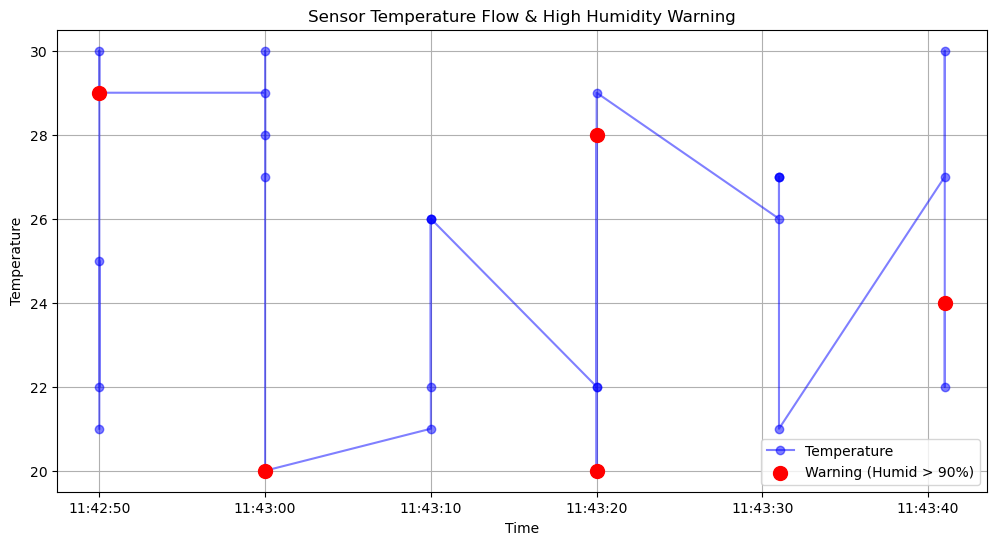

In [3]:
import threading
import queue
import time
import random
import csv
import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# =============================================================================
# [공통 설정]
# =============================================================================
FILE_NAME = 'parm_data.csv'
exit_event = threading.Event() # 프로그램 종료 신호

# =============================================================================
# [사진 3 구현 부분] - 큐(Queue) 생성
# 요구사항: 큐의 이름은 sensorQ, FIFO 구조
# =============================================================================
sensorQ = queue.Queue()

# =============================================================================
# [사진 1 구현 부분] - 스마트 팜 센서 구현
# 요구사항: ParmSensor 클래스, SetData(랜덤값), GetData, 고유이름
# =============================================================================
class ParmSensor:
    def __init__(self, name):
        self.name = name
        self.temp = 0
        self.light = 0
        self.humid = 0

    def SetData(self):
        # 요구사항: 각 센서 값은 지정된 범위 내 랜덤 생성
        self.temp = random.randint(20, 30)       # 온도: 20~30
        self.light = random.randint(5000, 10000) # 조도: 5000~10000
        self.humid = random.randint(40, 70)      # 습도: 40~70
        
        # [사진 3 보너스 과제 테스트용]
        # 습도가 90% 넘는 경우를 확인하기 위해 강제로 가끔 높은 값 생성
        if random.random() < 0.1: 
            self.humid = random.randint(91, 100)

    def GetData(self):
        return self.name, self.temp, self.light, self.humid

# =============================================================================
# [사진 2 구현 부분] - 데이터 저장 기능
# 요구사항: insert_sensor_data() 함수 구현 (SQL 대신 CSV로 대체)
# =============================================================================
def init_storage():
    """저장소(CSV) 초기화 및 헤더 생성"""
    if not os.path.exists(FILE_NAME):
        with open(FILE_NAME, mode='w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            # 사진 2의 테이블 구조: ID(자동), 입력시간, 온도, 조도, 습도
            # (CSV에서는 ID를 생략하거나 행 번호로 대체 가능)
            writer.writerow(['input_time', 'sensor_name', 'temp', 'light', 'humid'])

def insert_sensor_data(data):
    """
    요구사항: 입력시간, 온도, 조도, 습도 등을 입력받아 저장하는 함수
    """
    try:
        with open(FILE_NAME, mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            # data = (name, temp, light, humid, time_obj)
            name, temp, light, humid, time_obj = data
            time_str = time_obj.strftime('%Y-%m-%d %H:%M:%S')
            writer.writerow([time_str, name, temp, light, humid])
    except Exception as e:
        print(f"저장 오류: {e}")

# =============================================================================
# [사진 3 구현 부분] - 데이터 큐 활용 및 스레드
# 요구사항: 스레드에서 큐 확인, 1초 단위 호출, get_sensor_data() 구현
# =============================================================================

def get_sensor_data():
    """
    요구사항: 저장된 데이터를 가져오는 함수
    """
    if not os.path.exists(FILE_NAME):
        return pd.DataFrame()
    
    df = pd.read_csv(FILE_NAME)
    df['input_time'] = pd.to_datetime(df['input_time'])
    return df

def producer_task(sensor):
    """
    [사진 1 & 3 통합]
    - Parm1~5 인스턴스별 동작
    - 10초 단위로 데이터 생성 -> 화면 출력 -> sensorQ에 저장
    """
    while not exit_event.is_set():
        sensor.SetData()
        name, temp, light, humid = sensor.GetData()
        now = datetime.now()
        
        # [사진 1 요구사항] 화면 출력 포맷
        # 2000-08-01 14:30:30 Parm1 — temp 00, light 000, humi 00
        print(f"{now.strftime('%Y-%m-%d %H:%M:%S')} {name} — temp {temp}, light {light}, humi {humid}")
        
        # [사진 3 요구사항] DB 직접 입력하지 않고 큐(sensorQ)에 저장
        sensorQ.put((name, temp, light, humid, now))
        
        time.sleep(10) # 10초 대기

def consumer_task():
    """
    [사진 3 요구사항]
    - 별도의 스레드에서 1초에 한 번씩 큐 확인
    - 내용이 있으면 가져와서 insert_sensor_data() 호출
    """
    while not exit_event.is_set():
        if not sensorQ.empty():
            data = sensorQ.get() # FIFO (먼저 들어온 데이터부터)
            insert_sensor_data(data)
            sensorQ.task_done()
        
        time.sleep(1) # 1초 대기

# =============================================================================
# [메인 실행부] - 전체 시나리오 통합
# =============================================================================
if __name__ == '__main__':
    print("=== 스마트 팜 시스템 시작 ===")
    init_storage() # 저장소 준비
    
    # 1. 센서 인스턴스 5개 생성 (Parm1 ~ Parm5) - [사진 1]
    sensors = [ParmSensor(f"Parm-{i+1}") for i in range(5)]
    
    threads = []
    
    # 2. Consumer 스레드 (DB 저장 담당) 시작 - [사진 3]
    ct = threading.Thread(target=consumer_task)
    ct.start()
    threads.append(ct)
    
    # 3. Producer 스레드 (센서 데이터 생성 담당) 시작 - [사진 1, 3]
    for sensor in sensors:
        pt = threading.Thread(target=producer_task, args=(sensor,))
        pt.start()
        threads.append(pt)
        
    try:
        # 60초 동안 시스템 가동 (데이터 수집)
        print(">> 시스템 가동 중... (60초 뒤 결과 출력)")
        time.sleep(60)
        
    except KeyboardInterrupt:
        print(">> 강제 종료 요청")
        
    finally:
        print(">> 시스템 종료 중...")
        exit_event.set()
        for t in threads:
            t.join()
            
        print(">> 데이터 수집 완료. 결과 분석 시작.")
        
        # =====================================================================
        # [보너스 과제 구현]
        # =====================================================================
        df = get_sensor_data()
        
        if not df.empty:
            # [사진 1 보너스] 5분 단위 평균 (여기서는 데이터가 적으므로 전체 평균으로 대체 가능성 있음)
            # resample을 위해 인덱스 설정
            df_idx = df.set_index('input_time')
            
            # 센서별, 5분(5T) 단위 평균
            print("\n[보너스 1] 센서별 5분 단위 평균:")
            # 숫자형 컬럼만 선택하여 평균 계산
            numeric_cols = ['temp', 'light', 'humid']
            # 그룹화 및 리샘플링
            try:
                mean_df = df_idx.groupby('sensor_name')[numeric_cols].resample('5T').mean()
                print(mean_df)
            except Exception as e:
                print("데이터가 부족하여 5분 평균을 계산할 수 없습니다. (전체 평균으로 대체)")
                print(df.groupby('sensor_name')[numeric_cols].mean())

            # [사진 3 시각화 & 보너스]
            # - 시간별 온도 평균 그래프
            # - 습도 90% 이상 빨간색 표시
            plt.figure(figsize=(12, 6))
            
            # 전체 온도 흐름 그리기
            plt.plot(df['input_time'], df['temp'], label='Temperature', color='blue', marker='o', alpha=0.5)
            
            # 습도 90% 이상 포인트 찾기
            high_humid = df[df['humid'] > 90]
            if not high_humid.empty:
                plt.scatter(high_humid['input_time'], high_humid['temp'], color='red', s=100, label='Warning (Humid > 90%)', zorder=5)
                
            plt.title('Sensor Temperature Flow & High Humidity Warning')
            plt.xlabel('Time')
            plt.ylabel('Temperature')
            plt.legend()
            plt.grid(True)
            plt.show()
            
        else:
            print("저장된 데이터가 없습니다.")